In [42]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pip
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_auc_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.tree import export_graphviz


 

In [43]:
dataset = pd.read_csv(r'C:\Users\User\Downloads\Bank Customer Churn Prediction.csv')

Analise Exploratória

In [44]:
dataset.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [45]:
dataset.shape

(10000, 12)

In [46]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 1.0 MB


In [47]:
# Distribuição do churn
contagem = dataset['churn'].value_counts()
porcentagem = dataset['churn'].value_counts(normalize=True) * 100

print('Clientes que ficaram :', contagem[0], f'— {porcentagem[0]:.1f}%')
print('Clientes que saíram :', contagem[1], f'— {porcentagem[1]:.1f}%')

Clientes que ficaram : 7963 — 79.6%
Clientes que saíram : 2037 — 20.4%


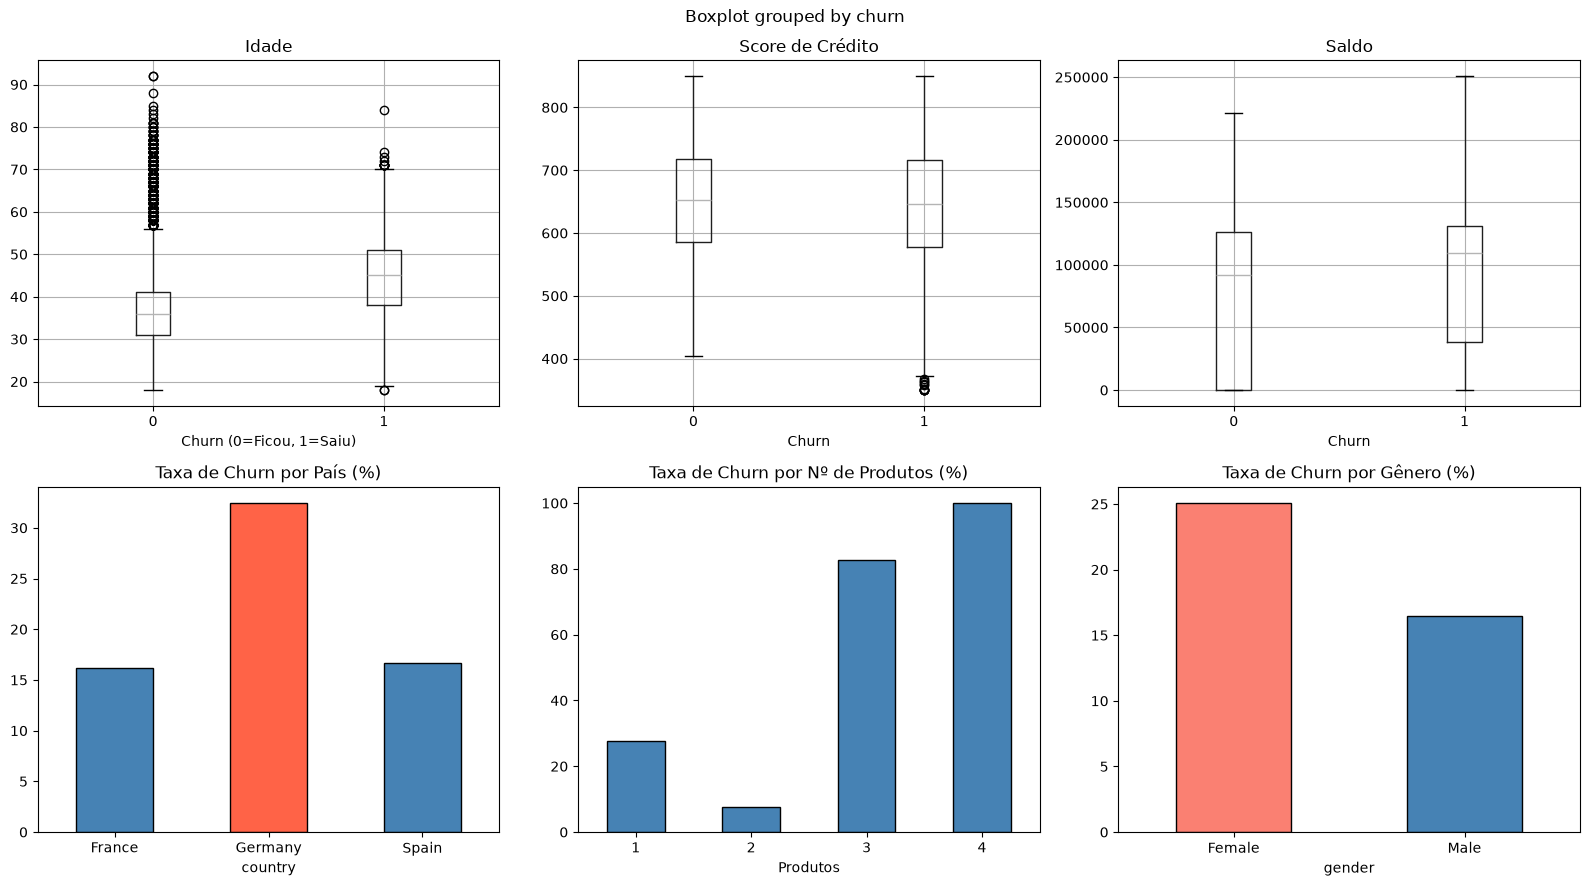

In [49]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Relação das variáveis com Churn', fontsize=14, fontweight='bold')

# Idade
dataset.boxplot(column='age', by='churn', ax=axes[0, 0])
axes[0, 0].set_title('Idade')
axes[0, 0].set_xlabel('Churn (0=Ficou, 1=Saiu)')

# Score de crédito
dataset.boxplot(column='credit_score', by='churn', ax=axes[0, 1])
axes[0, 1].set_title('Score de Crédito')
axes[0, 1].set_xlabel('Churn')

# Saldo
dataset.boxplot(column='balance', by='churn', ax=axes[0, 2])
axes[0, 2].set_title('Saldo')
axes[0, 2].set_xlabel('Churn')

# Churn por país
churn_pais = dataset.groupby('country')['churn'].mean() * 100
churn_pais.plot(kind='bar', ax=axes[1, 0], color=['steelblue', 'tomato', 'steelblue'], edgecolor='black')
axes[1, 0].set_title('Taxa de Churn por País (%)')
axes[1, 0].tick_params(axis='x', rotation=0)

# Churn por número de produtos
churn_prod = dataset.groupby('products_number')['churn'].mean() * 100
churn_prod.plot(kind='bar', ax=axes[1, 1], color='steelblue', edgecolor='black')
axes[1, 1].set_title('Taxa de Churn por Nº de Produtos (%)')
axes[1, 1].set_xlabel('Produtos')
axes[1, 1].tick_params(axis='x', rotation=0)

# Churn por gênero
churn_gen = dataset.groupby('gender')['churn'].mean() * 100
churn_gen.plot(kind='bar', ax=axes[1, 2], color=['salmon', 'steelblue'], edgecolor='black')
axes[1, 2].set_title('Taxa de Churn por Gênero (%)')
axes[1, 2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('eda_churn.png', dpi=150, bbox_inches='tight')
plt.show()

Conventer texto pra número

In [ ]:

df = dataset.drop(columns=['customer_id'])

# Converter texto para número
encoder = LabelEncoder()
dataset['country'] = encoder.fit_transform(dataset['country'])  # France=0, Germany=1, Spain=2
dataset['gender']  = encoder.fit_transform(dataset['gender'])   # Female=0, Male=1

# Confirmar
print('country agora é numérico:', dataset['country'].unique())
print('gender agora é numérico: ', dataset['gender'].unique())

country agora é numérico: [0 2 1]
gender agora é numérico:  [0 1]
